## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [9]:
import requests


# Coordenadas de Kuna en Bilbao + parámetros que vamos a necesitar de la API:
latitude = 43.2540
longitude = -2.9230
hourly = "temperature_2m"
timezone = "auto" #para que localice la hora local según la ubicación que necesites


url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [10]:
#Configuración de la petición (metemos en un diccionario los parámetros que vamos a utilizar como claves y sus valores):
params = {"latitude": 43.2540, "longitude": -2.9230, "hourly": "temperature_2m", "timezone": "auto"}

#Ejecución para procesar en formato JSON:
response = requests.get(url, params=params)
data = response.json()

#Acceso a los datos. Creamos dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes:
tiempos = data['hourly']['time']
temperaturas = data['hourly']['temperature_2m']

In [11]:
tiempos

['2026-03-23T00:00',
 '2026-03-23T01:00',
 '2026-03-23T02:00',
 '2026-03-23T03:00',
 '2026-03-23T04:00',
 '2026-03-23T05:00',
 '2026-03-23T06:00',
 '2026-03-23T07:00',
 '2026-03-23T08:00',
 '2026-03-23T09:00',
 '2026-03-23T10:00',
 '2026-03-23T11:00',
 '2026-03-23T12:00',
 '2026-03-23T13:00',
 '2026-03-23T14:00',
 '2026-03-23T15:00',
 '2026-03-23T16:00',
 '2026-03-23T17:00',
 '2026-03-23T18:00',
 '2026-03-23T19:00',
 '2026-03-23T20:00',
 '2026-03-23T21:00',
 '2026-03-23T22:00',
 '2026-03-23T23:00',
 '2026-03-24T00:00',
 '2026-03-24T01:00',
 '2026-03-24T02:00',
 '2026-03-24T03:00',
 '2026-03-24T04:00',
 '2026-03-24T05:00',
 '2026-03-24T06:00',
 '2026-03-24T07:00',
 '2026-03-24T08:00',
 '2026-03-24T09:00',
 '2026-03-24T10:00',
 '2026-03-24T11:00',
 '2026-03-24T12:00',
 '2026-03-24T13:00',
 '2026-03-24T14:00',
 '2026-03-24T15:00',
 '2026-03-24T16:00',
 '2026-03-24T17:00',
 '2026-03-24T18:00',
 '2026-03-24T19:00',
 '2026-03-24T20:00',
 '2026-03-24T21:00',
 '2026-03-24T22:00',
 '2026-03-24T

In [12]:
temperaturas

[12.5,
 12.3,
 12.1,
 11.8,
 11.5,
 11.1,
 10.7,
 10.8,
 11.0,
 12.0,
 13.2,
 14.1,
 15.0,
 15.4,
 14.7,
 14.8,
 15.9,
 15.5,
 15.3,
 14.5,
 13.2,
 12.3,
 11.6,
 10.9,
 10.0,
 9.2,
 8.6,
 8.2,
 7.8,
 7.7,
 7.7,
 7.6,
 8.8,
 10.6,
 13.3,
 15.5,
 17.2,
 18.7,
 19.9,
 20.7,
 20.1,
 19.5,
 18.6,
 17.5,
 16.1,
 14.1,
 12.5,
 11.7,
 11.8,
 11.4,
 11.3,
 11.0,
 10.5,
 10.6,
 10.9,
 10.9,
 11.5,
 12.7,
 13.6,
 13.9,
 13.1,
 11.7,
 11.2,
 10.8,
 10.6,
 10.1,
 10.0,
 9.5,
 9.4,
 9.0,
 9.0,
 8.9,
 8.8,
 8.6,
 8.9,
 8.5,
 8.4,
 8.5,
 8.6,
 8.3,
 8.6,
 9.0,
 9.8,
 10.4,
 10.8,
 11.6,
 12.1,
 12.2,
 12.0,
 11.5,
 11.0,
 10.1,
 9.1,
 8.2,
 7.4,
 6.9,
 6.6,
 6.5,
 6.1,
 5.8,
 5.8,
 6.3,
 6.4,
 6.5,
 7.0,
 8.5,
 10.4,
 10.7,
 11.3,
 11.7,
 11.7,
 11.5,
 11.1,
 10.4,
 9.6,
 8.6,
 7.6,
 6.5,
 5.5,
 4.6,
 3.8,
 3.2,
 2.9,
 2.8,
 2.7,
 2.6,
 2.4,
 2.3,
 7.2,
 8.5,
 9.7,
 10.7,
 11.5,
 12.0,
 12.3,
 12.3,
 12.1,
 11.8,
 11.3,
 10.9,
 10.6,
 10.4,
 10.1,
 9.7,
 9.2,
 8.9,
 8.8,
 8.9,
 8.9,
 8.8,
 8.5,
 8.6,


In [13]:
import pandas as pd

In [14]:
#Creamos un dataframe a partir de las 2 listas que hemos sacado de la API. Me parece la manera más fácil de hacerlo y entenderlo:
dataframe = pd.DataFrame({"Hora": tiempos, "Temperatura": temperaturas})
dataframe

,Hora,Temperatura
0,2026-03-23T00:00,12.5
1,2026-03-23T01:00,12.3
2,2026-03-23T02:00,12.1
3,2026-03-23T03:00,11.8
4,2026-03-23T04:00,11.5
...,...,...
163,2026-03-29T19:00,9.5
164,2026-03-29T20:00,9.2
165,2026-03-29T21:00,9.0
166,2026-03-29T22:00,8.9


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

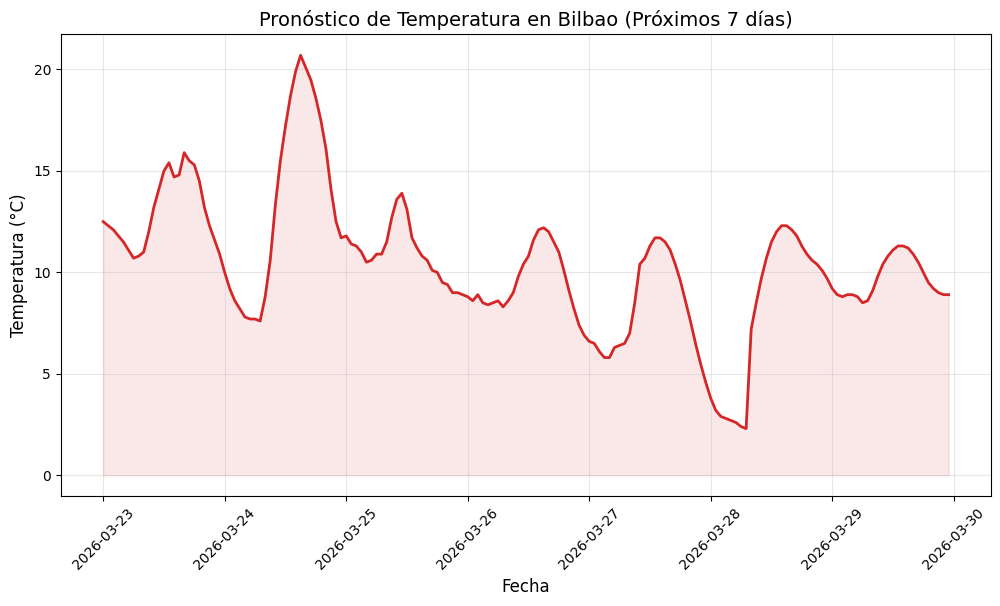

In [ ]:
#Para visualizar el pronóstico de temperaturas, la opción más adecuada es un gráfico de líneas, ya que permite observar claramente la evolución temporal 
#y los ciclos diarios (máximas y mínimas) a lo largo de la semana:

# Para ello, primero configuramos el estilo:
plt.figure(figsize=(12, 6))
dataframe['Hora'] = pd.to_datetime(dataframe['Hora']) #la columna "Hora" es un string por lo que hay que cambiarlo a formato hora mediante este comando
#Esto lo hemos hecho porque si lo dejas en formato "string", la coordenada x printea todos los datos (es decir, 24 datos/día x 7 días) y no es legible

plt.plot(dataframe["Hora"], dataframe["Temperatura"], color='tab:red', marker='', linestyle='-', linewidth=2)

#Decidimos añadirle sombreado bajo la línea:
plt.fill_between(dataframe["Hora"], dataframe["Temperatura"], color='tab:red', alpha=0.1)

#Personalización:
plt.title('Pronóstico de Temperatura en Bilbao (Próximos 7 días)', fontsize=14) #características título
plt.xlabel('Fecha', fontsize=12) #características coordenada x. Si dejábamos las horas en string, no se leía el eje x, por lo que hemos limitado el gráfico a 1 dato por día
plt.ylabel('Temperatura (°C)', fontsize=12) #características coordenada y
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45) #se giran 45 grados los datos del eje x para mejor visualización

plt.show()